In [1]:
#%%
# Standard library imports
from argparse import ArgumentParser
import os, sys
VENV_PATH = "/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/.venv/lib/python3.9/site-packages"
if VENV_PATH not in sys.path:
    sys.path.append(VENV_PATH)

import pytorch_lightning as pl
print(f"Success! Lightning Version: {pl.__version__}")
print(sys.executable)
THIS_DIR = os.path.abspath('')
PARENT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.append(PARENT_DIR)

# Third party imports
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint
from torchdiffeq import odeint
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np

# local application imports
from lag_caVAE.lag import Lag_Net
from lag_caVAE.nn_models import MLP_Encoder, MLP, MLP_Decoder, PSD
from hyperspherical_vae.distributions import VonMisesFisher
from hyperspherical_vae.distributions import HypersphericalUniform
from utils import arrange_data, from_pickle, my_collate, ImageDataset
from examples.pend_lag_cavae_trainer import Model

seed_everything(0)
%matplotlib inline
DPI = 600

/Users/harshit/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Success! Lightning Version: 0.8.5
/Library/Developer/CommandLineTools/usr/bin/python3


## Load Model

In [2]:
checkpoint_path = os.path.join(PARENT_DIR, 
                               'results', 
                               'pend',
                               'pend-lag-cavae-T_p=4-epoch=725-step=5807_0_horizontal_frozen_enc_dec.ckpt')

# checkpoint_path = os.path.join(PARENT_DIR, 
#                                'results', 
#                                'pend',
#                                'pend-lag-cavae-T_p=4-epoch=829-step=6639.ckpt')

model = Model.load_from_checkpoint(checkpoint_path)

In [3]:
ckpt = torch.load(checkpoint_path, map_location="cpu")
ckpt.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])

In [4]:
print(ckpt['callbacks'])

{"ModelCheckpoint{'monitor': 'monitor', 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None, 'save_on_train_epoch_end': True}": {'monitor': 'monitor', 'best_model_score': tensor(13.5432), 'best_model_path': '/var/lib/condor/execute/slot1/dir_378472/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=725-step=5807.ckpt', 'current_score': tensor(13.5432), 'dirpath': '/var/lib/condor/execute/slot1/dir_378472/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints', 'best_k_models': {'/var/lib/condor/execute/slot1/dir_378472/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=725-step=5807.ckpt': tensor(13.5432)}, 'kth_best_model_path': '/var/lib/condor/execute/slot1/dir_378472/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=725-step=5

## Prepare data

In [5]:
data_path=os.path.join(PARENT_DIR, 'datasets', 'pendulum-gym-image-dataset-test-with-0-control-horizontal.pkl')
print(data_path)
test_dataset = ImageDataset(data_path, 19, ctrl=True)

test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=my_collate)

/Users/harshit/Documents/UWM/F25/799-IS/Lagrangian_caVAE-main/datasets/pendulum-gym-image-dataset-test-with-0-control-horizontal.pkl


In [6]:
# test_batch = next(iter(test_dataloader))
# X, u = test_batch
# print(torch.unique(u))

In [7]:
for i, batch in enumerate(test_dataloader):
    X, u = batch
    
    # Calculate unique values for the current batch
    unique_vals = torch.unique(u)
    
    print(f"Batch {i}: Unique u values are {unique_vals}")

all_batches = list(test_dataloader)
X, u = all_batches[0]
print(torch.unique(u))

Batch 0: Unique u values are tensor([0.])
tensor([0.])


In [8]:
# model.t_eval = torch.from_numpy(test_dataset.t_eval)
def extend_t_eval(t_eval, N_new):
    t_eval = np.asarray(t_eval)
    dt = t_eval[1] - t_eval[0]
    t0 = t_eval[0]
    return t0 + dt * np.arange(N_new)
t_eval = torch.from_numpy(test_dataset.t_eval)
extended = torch.tensor(extend_t_eval(t_eval, 60))
model.t_eval = extended
model.hparams.solver = 'rk4'
model(X, u)

/Users/harshit/Library/Python/3.9/lib/python/site-packages/torch/distributions/distribution.py:51: UserWarning: <class 'hyperspherical_vae.distributions.hyperspherical_uniform.HypersphericalUniform'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(f'{self.__class__} does not define `arg_constraints`. ' +
/Users/harshit/Library/Python/3.9/lib/python/site-packages/torch/nn/functional.py:4298: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/Users/harshit/Library/Python/3.9/lib/python/site-packages/torch/nn/functional.py:4236: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior 

torch.Size([20, 256, 32, 32])


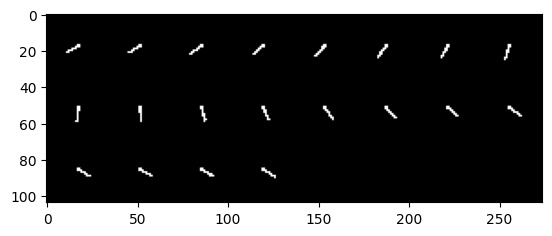

In [9]:
# data trajectory
b_ind = 0
print(X.shape)
grid = utils.make_grid(X[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17419674..1.3302565].


torch.Size([60, 256, 32, 32])


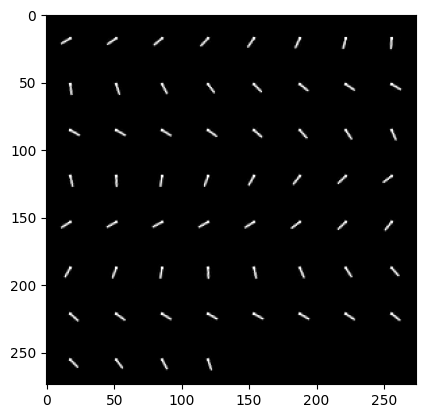

In [10]:
# prediction trajectory
print(model.Xrec.shape)
grid = utils.make_grid(model.Xrec[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

## Plot learned potential energy

In [11]:
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

Text(0, 0.5, '$V(\\phi)$')

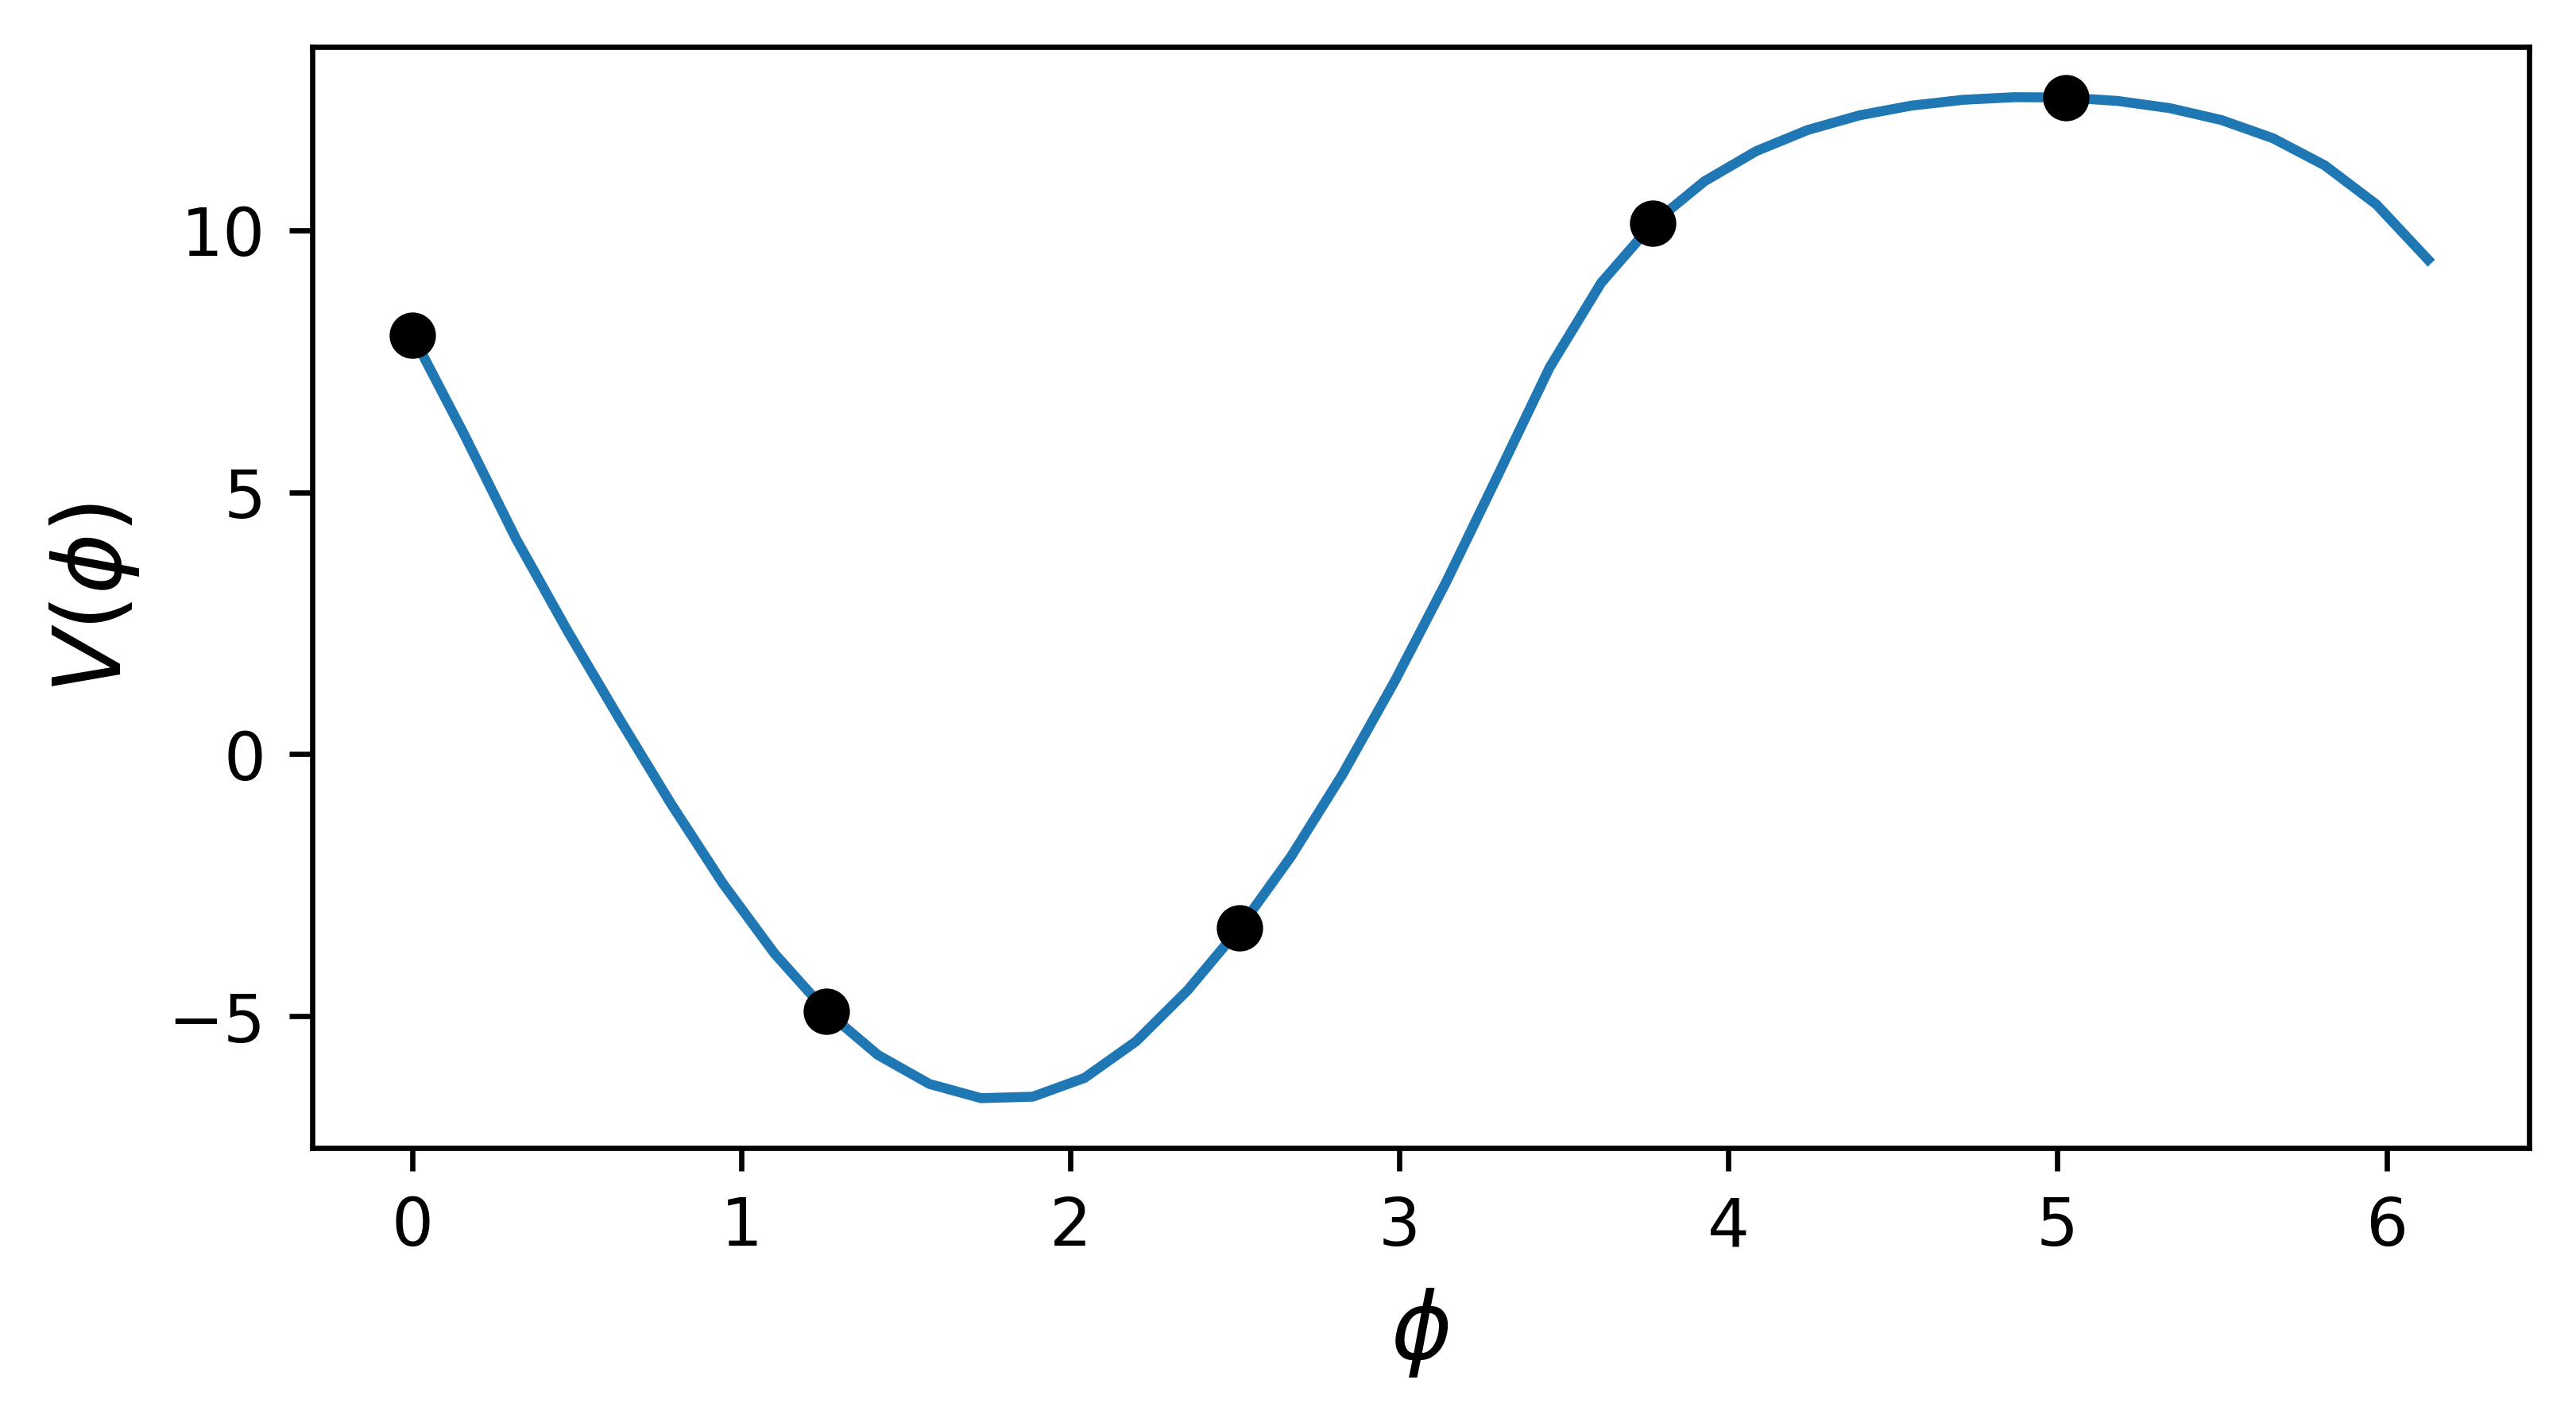

In [12]:
V_q = model.ode.V_net(cos_q_sin_q).detach().cpu().numpy()
fig = plt.figure(figsize=[6, 3], dpi=DPI)
markers_on = [0, 8, 16, 24, 32]
plt.plot(q[:-1], V_q, marker = 'o', markevery=markers_on, markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$V(\phi)$", fontsize=14)
# plt.tight_layout()
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend_potential_energy'), bbox_inches='tight')

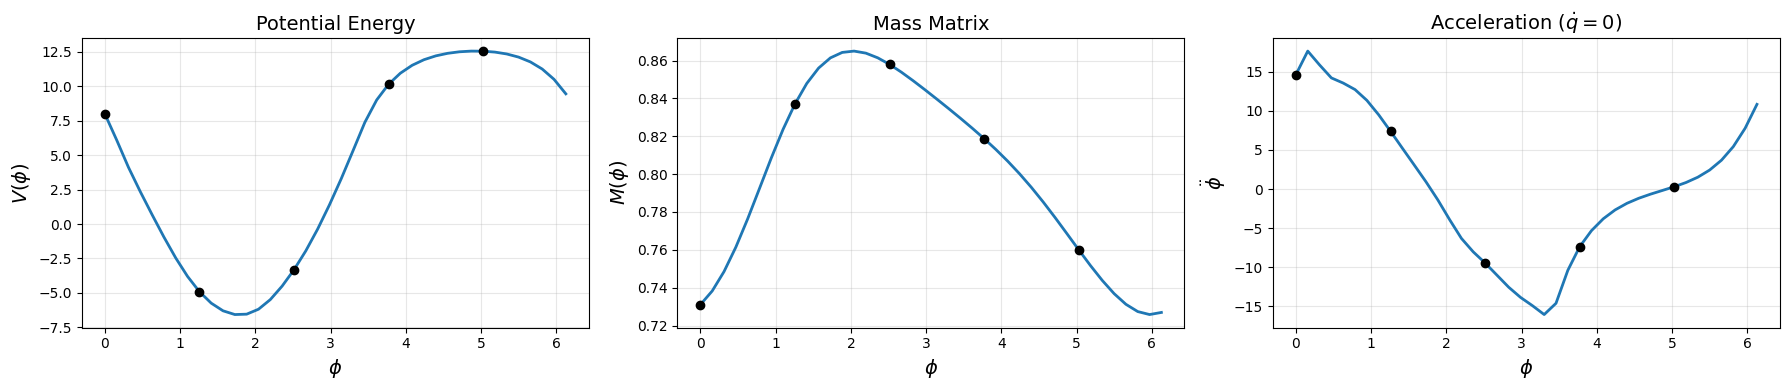

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Inputs (0 to 2pi)
# We need 'requires_grad=True' to calculate acceleration via derivatives
q_range = np.linspace(0, 2*np.pi, 41)
q_tensor = torch.tensor(q_range[:-1], dtype=torch.float32, requires_grad=True)

# Create cos/sin inputs
cos_q = torch.cos(q_tensor)
sin_q = torch.sin(q_tensor)
cos_q_sin_q = torch.stack((cos_q, sin_q), axis=1)

# 2. Forward Pass (Get V and M)
V_pred = model.ode.V_net(cos_q_sin_q)
M_pred = model.ode.M_net(cos_q_sin_q) 

# 3. Calculate Acceleration
# Physics: acc = - (1/M) * (dV/dq)
# Get gradient of V w.r.t q
d_V_dq = torch.autograd.grad(outputs=V_pred.sum(), inputs=q_tensor, create_graph=False)[0]

# Compute acceleration (ensure M is correct shape for division)
if M_pred.dim() > 1:
    M_pred_sq = M_pred.squeeze()
else:
    M_pred_sq = M_pred

acc_pred = -1.0 * (1.0 / M_pred_sq) * d_V_dq

# 4. Convert to Numpy
q_np = q_tensor.detach().cpu().numpy()
V_np = V_pred.detach().cpu().numpy().flatten()
M_np = M_pred.detach().cpu().numpy().flatten()
acc_np = acc_pred.detach().cpu().numpy().flatten()

# 5. Plotting Side-by-Side
fig, axs = plt.subplots(1, 3, figsize=(18, 4), dpi=100)
markers_on = [0, 8, 16, 24, 32] # Markers for visual tracking

# Helper for consistent style
def setup_plot(ax, x, y, title, ylabel):
    ax.plot(x, y, marker='o', markevery=markers_on, 
            markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1), linewidth=2)
    ax.set_xlabel(r"$\phi$", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)

# Plot V_net
setup_plot(axs[0], q_np, V_np, "Potential Energy", r"$V(\phi)$")

# Plot M_net (The Mass Matrix)
setup_plot(axs[1], q_np, M_np, "Mass Matrix", r"$M(\phi)$")

# Plot Acceleration
setup_plot(axs[2], q_np, acc_np, "Acceleration ($\dot{q}=0$)", r"$\ddot{\phi}$")

plt.tight_layout()
plt.show()

In [14]:
print("\n\n=== DECODER (obs_net) ===")
for name, param in model.obs_net.named_parameters():
    print(f"\nLayer: {name} | Shape: {param.shape}")
    print(param.data)



=== DECODER (obs_net) ===

Layer: linear1.weight | Shape: torch.Size([100, 1])
tensor([[ 0.4999],
        [ 0.5791],
        [ 0.7240],
        [ 0.7421],
        [-0.2204],
        [ 0.7669],
        [ 0.4646],
        [ 0.2186],
        [ 0.8909],
        [-0.8371],
        [-0.4041],
        [ 0.0457],
        [ 0.6925],
        [-0.3961],
        [ 0.5447],
        [ 0.0450],
        [ 0.5077],
        [ 0.6884],
        [ 0.1344],
        [ 0.3413],
        [-0.2736],
        [-0.6476],
        [ 0.6100],
        [ 0.9766],
        [-0.8778],
        [ 0.1704],
        [-0.6413],
        [ 0.7271],
        [ 0.2916],
        [-0.3415],
        [-0.1319],
        [ 0.8037],
        [-0.5586],
        [-0.3332],
        [ 0.5865],
        [-0.8563],
        [-0.5486],
        [ 0.0101],
        [ 0.0972],
        [ 0.5206],
        [-0.5637],
        [ 0.5281],
        [-0.3895],
        [ 0.0231],
        [-0.6670],
        [ 0.6207],
        [-0.4916],
        [-0.4504],
       

## Plot 5 reconstruction images corresponding to the black dots

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20576449..1.3566107].


torch.Size([60, 256, 32, 32])
torch.Size([40, 1, 32, 32])


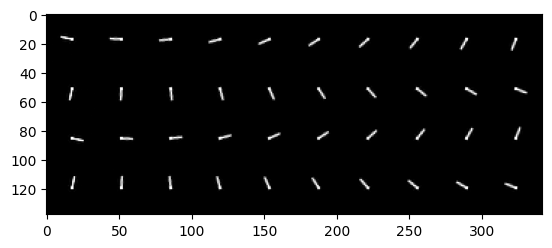

In [15]:
ones = torch.ones_like(cos_q_sin_q[:, 0:1])
content = model.obs_net(ones)

theta = model.get_theta_inv(cos_q_sin_q[:, 0], cos_q_sin_q[:, 1], 0, 0, bs=cos_q_sin_q.shape[0])
grid = F.affine_grid(theta, torch.Size((40, 1, 32, 32)))
Xrec = F.grid_sample(content.view(40, 1, 32, 32), grid)
print(model.Xrec.shape)
print(Xrec.shape)
fig = plt.figure()
grid = utils.make_grid(Xrec.view(40, 1, 32, 32), nrow=10)
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20576449..1.3566107].


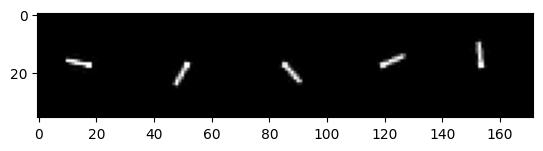

In [16]:
# for i in [0, 8, 16, 24, 32]:
#     fig = plt.figure()
#     plt.imshow(Xrec[i][0].detach().cpu().numpy(), cmap='gray')
#     plt.axis('off')
#     fig.savefig(os.path.join(PARENT_DIR, 'figures', f'pend_recon_{i}.png'), bbox_inches='tight')
grid = utils.make_grid(Xrec[0:40:8])
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

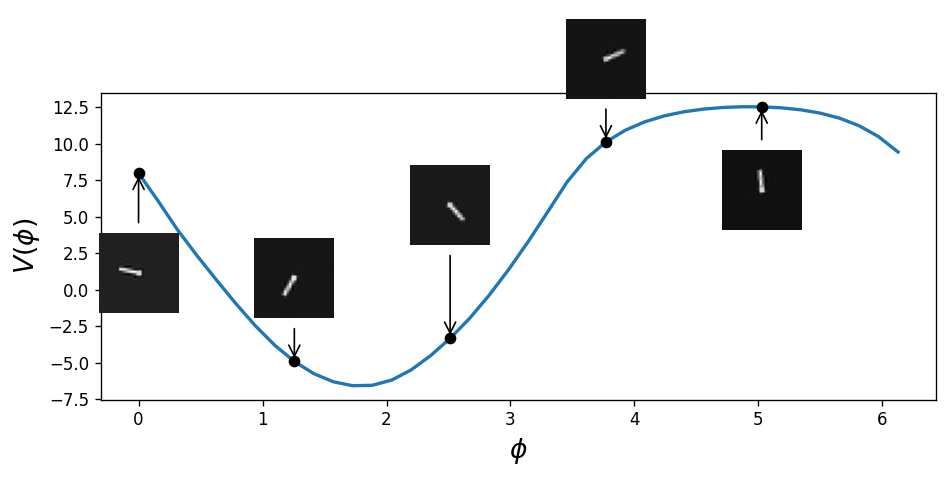

In [17]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ... (Run your existing data generation code for q, V_q, and Xrec here) ...

# 1. Setup the main figure
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

# 2. Plot the Potential Energy Curve
markers_on = [0, 8, 16, 24, 32]
ax.plot(q[:-1], V_q, marker='o', markevery=markers_on, 
        markerfacecolor='black', markeredgecolor='black', linewidth=2)

ax.set_xlabel(r"$\phi$", fontsize=16)
ax.set_ylabel(r"$V(\phi)$", fontsize=16)

# 3. Define offsets for the images to match the visual style of your upload
# (dx, dy) in 'points' relative to the data point. 
# You can tweak these to move the images up/down/left/right.
offsets = [
    (0, -60),  # Index 0:  Move image Down
    (0, 50),   # Index 8:  Move image Up
    (0, 80),   # Index 16: Move image Up (Longer arrow for the valley)
    (0, 50),   # Index 24: Move image Up
    (0, -50)   # Index 32: Move image Down
]

# 4. Loop through markers and overlay images
for i, idx in enumerate(markers_on):
    # Get the coordinate on the curve
    x_curr = q[idx]
    y_curr = V_q[idx]
    
    # Extract the image from Xrec (assuming shape [N, C, H, W])
    # We take the first channel [0] to get a 2D array (32x32)
    img_array = Xrec[idx, 0].detach().cpu().numpy()
    
    # Create an off-set image box
    # zoom controls the size of the thumbnail
    imagebox = OffsetImage(img_array, zoom=1.5, cmap='gray') 
    
    # Create the annotation
    # xy is the data point (dot), xybox is where the image sits
    ab = AnnotationBbox(imagebox, (x_curr, y_curr),
                        xybox=offsets[i],
                        boxcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color='black'),
                        frameon=False) # Remove the box border around the image
    
    ax.add_artist(ab)

# Clean up layout
plt.tight_layout()
plt.show()

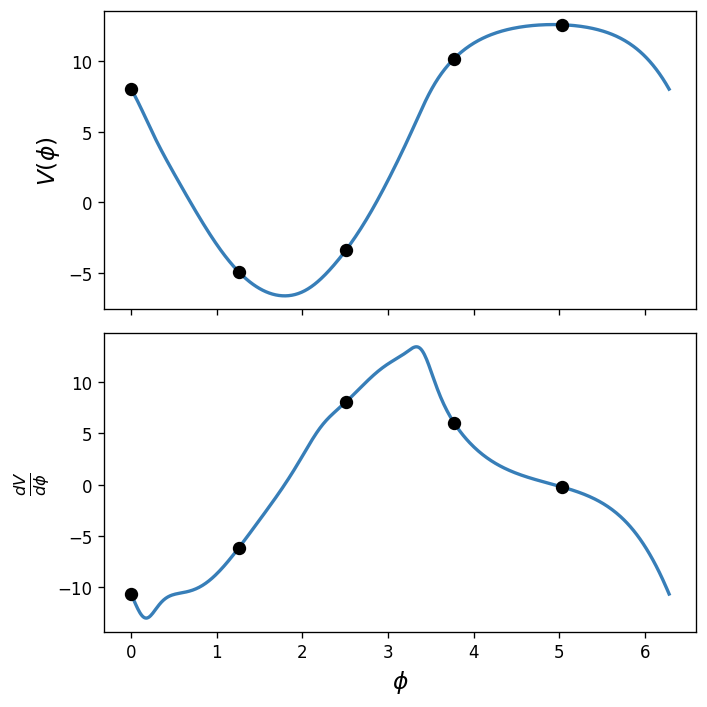

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# User's constants
DPI = 120

# ==========================================
# 1. PREPARE DATA
# ==========================================

# --- A. Dense Grid (For the smooth blue curve) ---
# We use 500 points to ensure the line looks like a curve, not polygons.
q_dense_np = np.linspace(0, 2*np.pi, 500)
q_dense = torch.tensor(q_dense_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the dense grid
cos_dense = torch.cos(q_dense)
sin_dense = torch.sin(q_dense)
x_dense = torch.stack((cos_dense, sin_dense), dim=1)


# --- B. Sparse Grid (For the black markers) ---
# This matches your original 40-point resolution logic
q_sparse_np = np.linspace(0, 2*np.pi, 41)[:-1] 
q_sparse = torch.tensor(q_sparse_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the sparse grid
cos_sparse = torch.cos(q_sparse)
sin_sparse = torch.sin(q_sparse)
x_sparse = torch.stack((cos_sparse, sin_sparse), dim=1)


# ==========================================
# 2. MODEL PASS & AUTOGRAD
# ==========================================
model.eval() # Important: Disables Dropout/BatchNorm noise

def get_V_and_grad(q_input, x_input):
    """Helper to forward pass and calculate gradient for any input resolution."""
    # 1. Forward Pass
    V_pred = model.ode.V_net(x_input)
    
    # 2. Backward Pass (Gradient)
    # We differentiate V_pred w.r.t q_input
    grads = torch.autograd.grad(
        outputs=V_pred,
        inputs=q_input,
        grad_outputs=torch.ones_like(V_pred),
        create_graph=False
    )[0]
    
    return V_pred.detach().cpu().numpy(), grads.detach().cpu().numpy()

# Calculate smooth curves
V_curve, dV_curve = get_V_and_grad(q_dense, x_dense)

# Calculate specific marker points
V_markers, dV_markers = get_V_and_grad(q_sparse, x_sparse)


# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=[6, 6], dpi=DPI, sharex=True)
markers_idx = [0, 8, 16, 24, 32] # Indices for the sparse array

# --- Top Plot: V(phi) ---
# 1. Plot the high-res line (Smooth)
ax[0].plot(q_dense_np, V_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[0].plot(q_sparse_np[markers_idx], V_markers[markers_idx], 
           marker='o', linestyle='None', # 'None' prevents drawing lines between dots
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[0].set_ylabel(r"$V(\phi)$", fontsize=14)

# --- Bottom Plot: dV/dphi ---
# 1. Plot the high-res line (Smooth) - THIS FIXES THE KINKS
ax[1].plot(q_dense_np, dV_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[1].plot(q_sparse_np[markers_idx], dV_markers[markers_idx], 
           marker='o', linestyle='None', 
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[1].set_ylabel(r"$\frac{dV}{d\phi}$", fontsize=14)
ax[1].set_xlabel(r"$\phi$", fontsize=14)

plt.tight_layout()
plt.show()

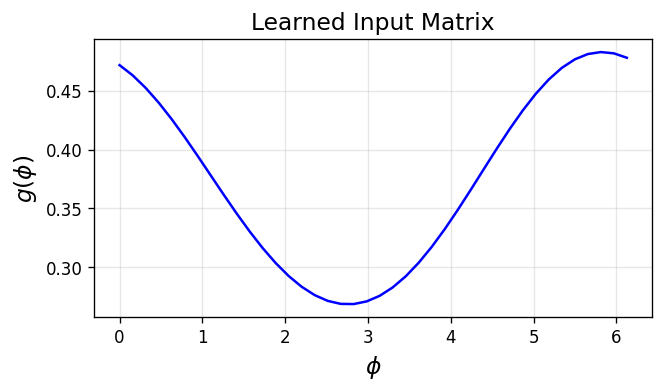

In [19]:
# 1. Prepare inputs (0 to 2pi) - effectively reusing the setup from the V_net cell
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

# 2. Forward pass through g_net
# The model instance (loaded from checkpoint) contains the ode module, which holds g_net
g_q = model.ode.g_net(cos_q_sin_q).detach().cpu().numpy()

# 3. Plot
fig = plt.figure(figsize=[6, 3], dpi=DPI)
plt.plot(q[:-1], g_q, 'b-') # Plotting g(phi) vs phi
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$g(\phi)$", fontsize=14)
plt.title("Learned Input Matrix", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

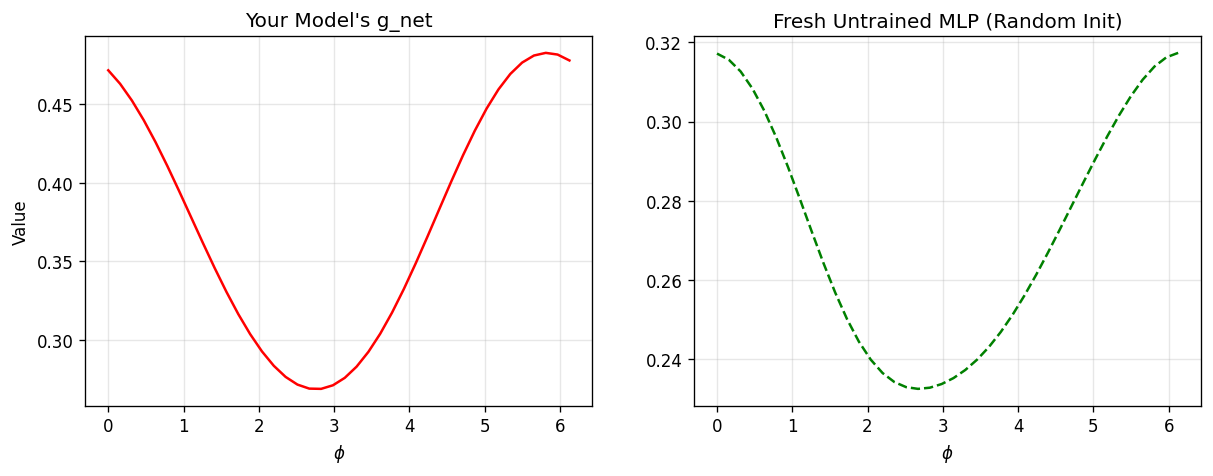

In [20]:
# 1. Plot the "Learned" g_net (from your loaded model)
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = torch.tensor(np.stack((cos_q, sin_q), axis=1), dtype=torch.float32)

g_learned = model.ode.g_net(cos_q_sin_q).detach().cpu().numpy()

# 2. Create a FRESH, UNTRAINED g_net (Random Initialization)
# Using the same architecture as defined in pend_lag_cavae_trainer.py
from lag_caVAE.nn_models import MLP
fresh_g_net = MLP(input_dim=2, hidden_dim=50, output_dim=1) 
g_random = fresh_g_net(cos_q_sin_q).detach().cpu().numpy()

# 3. Compare visually
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=DPI)

# Plot A: Your model
ax[0].plot(q[:-1], g_learned, 'r-', label='Model g_net (u=0 trained)')
ax[0].set_title("Your Model's g_net")
ax[0].set_xlabel(r"$\phi$")
ax[0].set_ylabel("Value")
ax[0].grid(alpha=0.3)

# Plot B: A completely random network
ax[1].plot(q[:-1], g_random, 'g--', label='Fresh Random MLP')
ax[1].set_title("Fresh Untrained MLP (Random Init)")
ax[1].set_xlabel(r"$\phi$")
ax[1].grid(alpha=0.3)

plt.show()

In [21]:
print(model.ode.g_net.linear1.weight[49, :5])
print("Fresh Random Net (linear1):")
print(fresh_g_net.linear1.weight[0, :5])

tensor([-0.1875,  0.1331], grad_fn=<SliceBackward0>)
Fresh Random Net (linear1):
tensor([-0.1059, -0.2184], grad_fn=<SliceBackward0>)


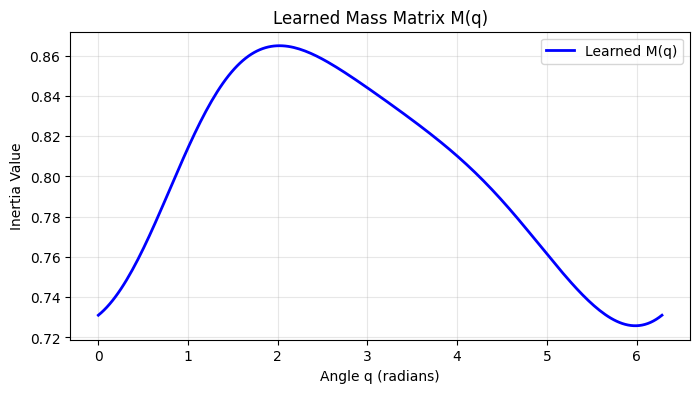

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_learned_mass(model):
    # 1. Generate a range of angles (q) from -pi to pi
    angles = np.linspace(0, 2*np.pi, 200)
    
    # 2. Prepare inputs: M_net expects [cos(q), sin(q)]
    # We cannot just feed the angle; the network is designed to work with trig values
    cos_q = np.cos(angles)
    sin_q = np.sin(angles)
    
    # Stack them into a tensor of shape (Batch_Size, 2)
    inputs_np = np.stack([cos_q, sin_q], axis=1)
    inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)

    # 3. Pass through the M_net
    model.eval() # Set to evaluation mode
    with torch.no_grad():
        # Access the mass network inside the ODE module
        # M_net outputs shape (Batch, 1) for a 1D pendulum
        mass_matrix = model.ode.M_net(inputs)

    # 4. Plot
    mass_values = mass_matrix.cpu().numpy().flatten()
    
    plt.figure(figsize=(8, 4))
    plt.plot(angles, mass_values, label='Learned M(q)', color='blue', linewidth=2)
    
    # Add labels
    plt.xlabel('Angle q (radians)')
    plt.ylabel('Inertia Value')
    plt.title('Learned Mass Matrix M(q)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Assuming your model variable is named 'model'
plot_learned_mass(model)

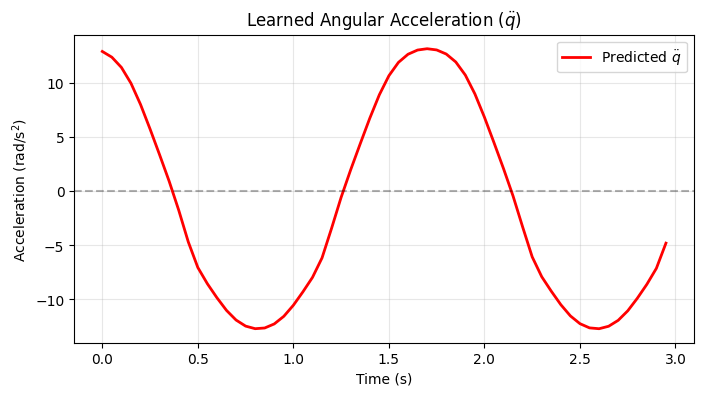

In [23]:
import torch
import matplotlib.pyplot as plt
from torchdiffeq import odeint

# 1. Prepare the model and input
model.eval()
z0_u = torch.cat((model.q0, model.q_dot0, u), dim=1).detach()
# We must enable gradients for the state so the Lagrangian physics work
z0_u.requires_grad = True 

# 2. Re-simulate the latent trajectory
# We explicitly enable grad here so model.ode can call torch.autograd.grad
with torch.set_grad_enabled(True):
    z_traj = odeint(model.ode, z0_u, model.t_eval, method=model.hparams.solver)

# 3. Compute the acceleration (q_double_dot)
T_steps, batch_size, _ = z_traj.shape
# Re-evaluate the ODE on the trajectory to extract derivatives
# We use set_grad_enabled(True) again for the internal autograd calls
with torch.set_grad_enabled(True):
    z_flat = z_traj.reshape(-1, 4)
    dz_dt_flat = model.ode(0, z_flat) 

# 4. Extract q_double_dot (index 2)
# Detach now to convert to numpy for plotting
q_ddot = dz_dt_flat[:, 2].detach().cpu().numpy()
q_ddot = q_ddot.reshape(T_steps, batch_size)
t_axis = model.t_eval.cpu().numpy()

# 5. Plotting
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(t_axis, q_ddot[:, 0], 'r-', linewidth=2, label=r'Predicted $\ddot{q}$')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('Time (s)')
plt.ylabel(r'Acceleration (rad/s$^2$)')
plt.title('Learned Angular Acceleration ($\ddot{q}$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

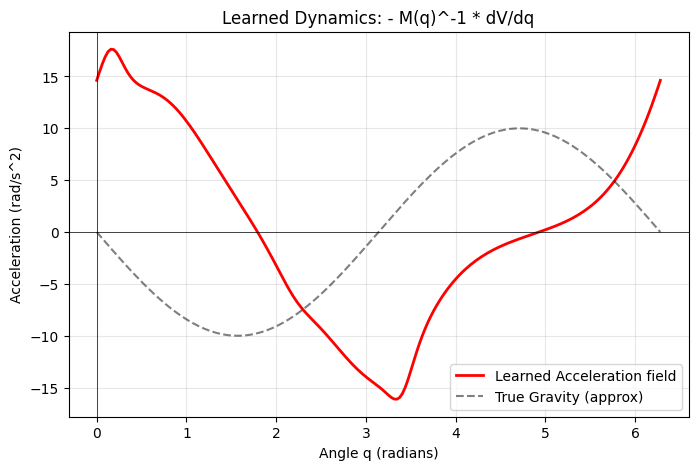

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_potential_acceleration(model):
    # 1. Prepare inputs: Range of angles from -pi to pi
    angles = np.linspace(0, 2*np.pi, 200)
    
    # Create tensor for [cos(q), sin(q)]
    # IMPORTANT: We need requires_grad=True to calculate forces (gradients)
    cos_q = np.cos(angles)
    sin_q = np.sin(angles)
    inputs_np = np.stack([cos_q, sin_q], axis=1)
    inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)
    inputs.requires_grad_(True) 

    # 2. Compute Potential Energy (V) and its gradient (Force)
    # We don't use model.eval() here because we need grad for the physics calculation,
    # but we won't be updating weights.
    
    V_q = model.ode.V_net(inputs)
    
    # Calculate dV/d(input)
    # This gives [dV/d(cos), dV/d(sin)]
    dV_dinput = torch.autograd.grad(V_q.sum(), inputs, create_graph=False)[0]
    
    # Chain Rule to get dV/dq (Force w.r.t Angle)
    # dV/dq = (dV/dcos * -sin) + (dV/dsin * cos)
    dV_dcos = dV_dinput[:, 0]
    dV_dsin = dV_dinput[:, 1]
    
    sin_q_tensor = inputs[:, 1]
    cos_q_tensor = inputs[:, 0]
    
    dV_dq = dV_dcos * (-sin_q_tensor) + dV_dsin * (cos_q_tensor)

    # 3. Compute Mass (M)
    with torch.no_grad():
        M_q = model.ode.M_net(inputs)
        # Flatten M_q (it comes out as batch, 1, 1 for pendulum)
        M_q = M_q.view(-1)

    # 4. Calculate Acceleration Field
    # a = - (1/M) * (dV/dq)
    # We detach() to convert to numpy for plotting
    acceleration = (-dV_dq / M_q).detach().cpu().numpy()

    # 5. Plot
    plt.figure(figsize=(8, 5))
    plt.plot(angles, acceleration, label='Learned Acceleration field', color='red', linewidth=2)
    plt.plot(angles, -10 * np.sin(angles), 'k--', alpha=0.5, label='True Gravity (approx)')
    
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlabel('Angle q (radians)')
    plt.ylabel('Acceleration (rad/s^2)')
    plt.title('Learned Dynamics: - M(q)^-1 * dV/dq')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the function
plot_potential_acceleration(model)

In [24]:
import torch
import numpy as np

# 1. Define the standard angles (Identical to Step 1)
angles = np.linspace(0, 2*np.pi, 200)
cos_q = np.cos(angles)
sin_q = np.sin(angles)
inputs_np = np.stack([cos_q, sin_q], axis=1)

# 2. Calculate Acceleration
inputs = torch.tensor(inputs_np, dtype=torch.float32).to(model.device)
inputs.requires_grad_(True)

V = model.ode.V_net(inputs)
dV_input = torch.autograd.grad(V.sum(), inputs, create_graph=False)[0]
dV_dq = dV_input[:, 0] * (-inputs[:, 1]) + dV_input[:, 1] * (inputs[:, 0])

with torch.no_grad():
    M = model.ode.M_net(inputs).view(-1)

accel_new = (-dV_dq / M).detach().cpu().numpy()

# 3. Save to file
np.save('acceleration_new.npy', accel_new)
print("Saved 'acceleration_new.npy'.")

Saved 'acceleration_new.npy'.


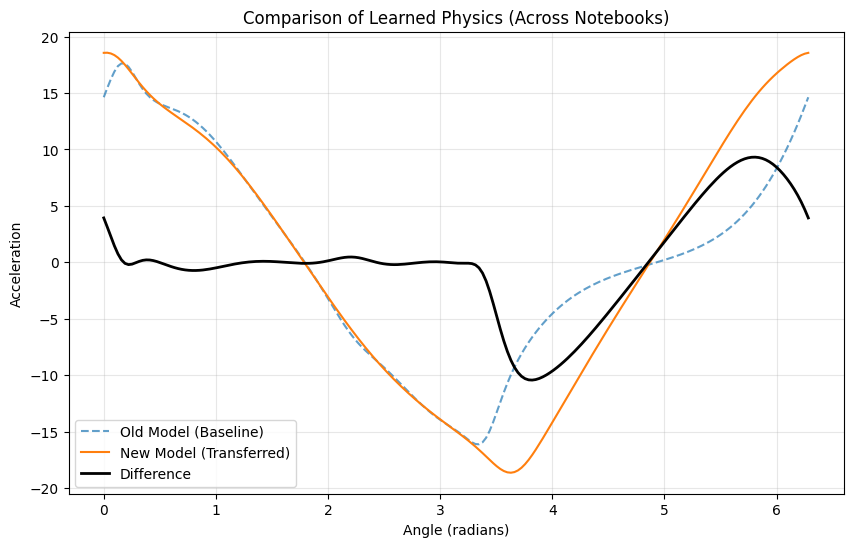

Mean Squared Error between models: 22.369888


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data
accel_old = np.load('acceleration_old.npy')
accel_new = np.load('acceleration_new.npy')

# Re-create the angle array for plotting
angles = np.linspace(0, 2*np.pi, 200)

# 2. Plot Comparison
plt.figure(figsize=(10, 6))
plt.plot(angles, accel_old, '--', label='Old Model (Baseline)', alpha=0.7)
plt.plot(angles, accel_new, '-', label='New Model (Transferred)')
plt.plot(angles, accel_new - accel_old, 'k-', linewidth=2, label='Difference')

plt.title("Comparison of Learned Physics (Across Notebooks)")
plt.xlabel("Angle (radians)")
plt.ylabel("Acceleration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Mathematical Sanity Check
mse = np.mean((accel_old - accel_new)**2)
print(f"Mean Squared Error between models: {mse:.6f}")

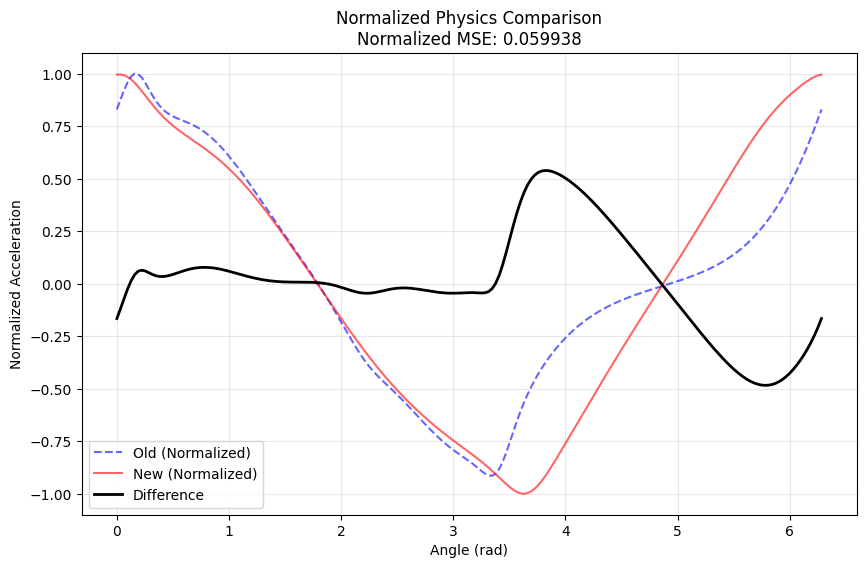

Normalized MSE: 0.059938
❌ FAILURE: The shapes still look different.
   The model did NOT learn the original dynamics correctly.


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the raw files
try:
    accel_old = np.load('acceleration_old.npy')
    accel_new = np.load('acceleration_new.npy')
except FileNotFoundError:
    print("❌ Error: Could not find .npy files. Make sure you ran Step 1 and 2!")
    raise

# 2. Normalize both curves
# We divide by the maximum absolute value to scale everything between -1 and 1.
# This cancels out the hidden 'Mass' multiplier.
norm_old = accel_old / np.max(np.abs(accel_old))
norm_new = accel_new / np.max(np.abs(accel_new))

# 3. Calculate Normalized MSE
mse_norm = np.mean((norm_old - norm_new)**2)

# 4. Plot Comparison
angles = np.linspace(0, 2*np.pi, 200)
plt.figure(figsize=(10, 6))
plt.plot(angles, norm_old, 'b--', label='Old (Normalized)', alpha=0.6)
plt.plot(angles, norm_new, 'r-', label='New (Normalized)', alpha=0.6)
plt.plot(angles, norm_old - norm_new, 'k-', linewidth=2, label='Difference')

plt.title(f"Normalized Physics Comparison\nNormalized MSE: {mse_norm:.6f}")
plt.xlabel("Angle (rad)")
plt.ylabel("Normalized Acceleration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. The Verdict
print(f"Normalized MSE: {mse_norm:.6f}")
if mse_norm < 0.05:
    print("✅ SUCCESS: The shapes match! The high error was just a scaling issue.")
    print("   Your Transfer Learning worked correctly.")
else:
    print("❌ FAILURE: The shapes still look different.")
    print("   The model did NOT learn the original dynamics correctly.")

# Control

In [18]:
import gym, myenv
import numpy as np
from skimage import color
from gym import wrappers
env = gym.make('MyPendulum-v0')

# prepare model instance
model.hparams.solver = 'rk4'
model.bs = 1
model.d = 32

# get a goal image
q_star = 0.0
env.reset()
env.state = np.array([q_star, 0.0], dtype=np.float32)
goal_frame = env.render(mode='rgb_array')
goal_frame = color.rgb2gray(goal_frame)
goal_frame = torch.tensor(goal_frame, dtype=torch.float32)
env.close()

# given a goal image, design controller
# first encode the goal image to goal coordinates
_, _, goal_q_n = model.encode(goal_frame.view(1, 32*32))

/usr/local/lib/python3.8/site-packages/gym/logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


ImportError: 
    Error occurred while running `from pyglet.gl import *`
    HINT: make sure you have OpenGL install. On Ubuntu, you can run 'apt-get install python-opengl'.
    If you're running on a server, you may need a virtual frame buffer; something like this should work:
    'xvfb-run -s "-screen 0 1400x900x24" python <your_script.py>'
    

In [ ]:
goal_q_n

In [ ]:
q0 = 3.14

env.reset()
env.state = np.array([q0, 0.0], dtype=np.float32)
frame = color.rgb2gray(env.render(mode='rgb_array'))
frames = [frame]

frame = torch.tensor(frame, dtype=torch.float32)

for i in range(100):
    _, _, q_n = model.encode(frame.view(1, 32*32))
    
    if i==0:
        prev_q_n = q_n
        
    q_dot = model.angle_vel_est(prev_q_n, q_n, 0.05)

    V_q = model.ode.V_net(q_n)
    dV = torch.autograd.grad(V_q, q_n)[0]
    dV_dcos_q, dV_dsin_q = dV.split([1, 1], dim=1)
    dV_dq = - dV_dcos_q * q_n[:, 1] + dV_dsin_q * q_n[:, 0]
    g_q = model.ode.g_net(q_n)

#     energy_shaping = torch.zeros(2, 1, dtype=torch.float32)
#     energy_shaping[0][0] = dV_dr[0][0] - 3* (r_cos_phi_sin_phi[0][0] - 0.0)
#     energy_shaping[1][0] = 2 * dV_dphi[0][0]

    energy_shaping = dV_dq - 6 * (q_n[0, 1] * goal_q_n[0, 0] - q_n[0, 0] * goal_q_n[0, 1])
    damping_injection = - 1 * q_dot.T

    u = 1/g_q * (energy_shaping + damping_injection)

    u = u.detach().cpu().numpy()
    env.step(u)

    frame = color.rgb2gray(env.render(mode='rgb_array'))
    frames.append(frame)
    frame = torch.tensor(frame, dtype=torch.float32)

    prev_q_n = q_n

env.close()

In [ ]:
fig = plt.figure(figsize=(16, 4), dpi=DPI)
for i in range(13):
    plt.subplot(1, 13, i+1)
    plt.imshow(frames[i*8], cmap='gray')
    plt.axis('off')
    
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.png'), bbox_inches='tight')

In [ ]:
# import imageio
# imageio.mimsave(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.gif'), frames, duration=0.05)

control animation ![control sequence](../figures/pend-ctrl.gif)

In [26]:
model.hparams

"T_pred":                            4
"accelerator":                       None
"accumulate_grad_batches":           None
"amp_backend":                       native
"amp_level":                         None
"annealing":                         False
"auto_lr_find":                      False
"auto_scale_batch_size":             False
"auto_select_gpus":                  False
"batch_size":                        512
"benchmark":                         False
"check_val_every_n_epoch":           1
"checkpoint_callback":               None
"default_root_dir":                  None
"detect_anomaly":                    False
"deterministic":                     False
"devices":                           None
"enable_checkpointing":              True
"enable_model_summary":              True
"enable_progress_bar":               True
"fast_dev_run":                      False
"flush_logs_every_n_steps":          None
"gpus":                              1
"gradient_clip_algorithm":        